Saving Concrete_Data_Yeh.csv to Concrete_Data_Yeh.csv
特征与抗压强度相关性：
csMPa               1.000000
cement              0.497832
superplasticizer    0.366079
age                 0.328873
slag                0.134829
flyash             -0.105755
coarseaggregate    -0.164935
fineaggregate      -0.167241
water              -0.289633
Name: csMPa, dtype: float64
ConcreteNet(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)
Epoch [50/300], Loss: 59.4520
Epoch [100/300], Loss: 30.4603
Epoch [150/300], Loss: 20.9322
Epoch [200/300], Loss: 15.4875
Epoch [250/300], Loss: 13.4424
Epoch [300/300], Loss: 12.5741

===== 三层神经网络 模型评估 =====
MSE  : 33.61
RMSE : 5.80
R²   : 0.870


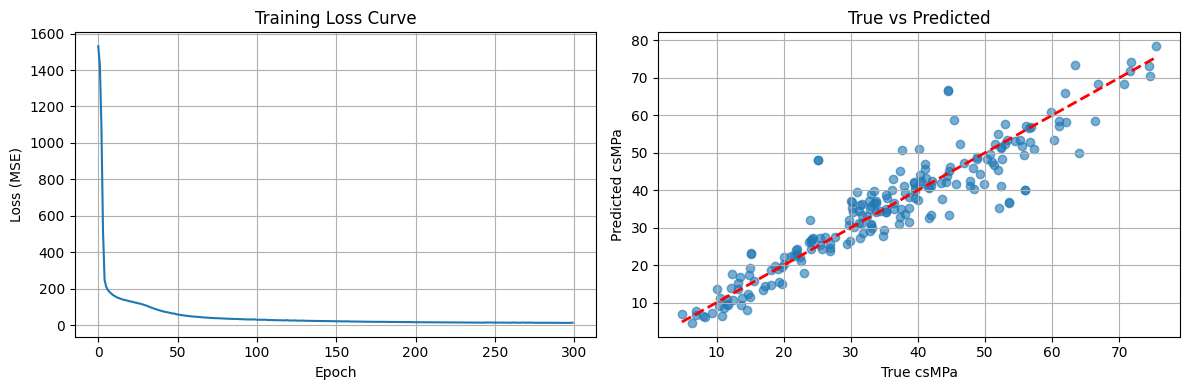

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# =====================读取数据=====================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Concrete_Data_Yeh.csv")

#特征与标签
X = df.drop("csMPa", axis=1).values
y = df["csMPa"].values

# =====================相关性分析=====================
corr = df.corr()
print("特征与抗压强度相关性：")
print(corr["csMPa"].sort_values(ascending=False))

# =====================划分训练集/测试集8:2=====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================标准化=====================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================转为PyTorch张量=====================
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

#构建DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# =====================构建三层神经网络=====================
class ConcreteNet(nn.Module):
    def __init__(self, input_dim=8):
        super(ConcreteNet, self).__init__()
        #三层网络：输入层→隐藏层1→隐藏层2→输出层
        self.fc1 = nn.Linear(input_dim, 64)   #第一层
        self.fc2 = nn.Linear(64, 32)       #第二层
        self.fc3 = nn.Linear(32, 16)         #第三层
        self.out = nn.Linear(16, 1)          #输出
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.out(x)
        return x

#初始化模型
model = ConcreteNet(input_dim=8)
print(model)

# =====================损失函数与优化器=====================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =====================训练模型=====================
epochs = 300
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

# =====================测试与评估=====================
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy().flatten()
    y_true = y_test_tensor.numpy().flatten()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\n=====模型评估=====")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

# =====================绘图=====================
plt.figure(figsize=(12, 4))

#损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.grid(True)

#真实值 vs 预测值
plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True csMPa")
plt.ylabel("Predicted csMPa")
plt.title("True vs Predicted")
plt.grid(True)

plt.tight_layout()
plt.show()

# 神经网络及其应用第一次实验报告
姓名：邢书一
学号：SA25219056

---

## 一、实验目的
1. 利用神经网络实现基于混凝土数据集完成抗压强度预测任务。
2. 理解PyTorch框架下数据预处理、模型构建、训练与评估的完整流程。
3. 掌握回归任务的评价指标（MSE、RMSE、R²）与可视化分析方法。

---

## 二、数据集与任务描述
- **数据集**：混凝土抗压强度数据集（Concrete_Data_Yeh.csv）
- **样本数量**：1030条
- **特征数量**：8个
  - cement（水泥）、slag（矿渣）、flyash（粉煤灰）、water（水）
  - superplasticizer（减水剂）、coarseaggregate（粗骨料）、fineaggregate（细骨料）、age（龄期）
- **预测目标**：混凝土抗压强度csMPa
- **数据分布**：抗压强度范围约2~80MPa，平均强度约35MPa。

---

## 三、实验原理
### 1. 三层全连接神经网络
本实验采用**输入层-隐藏层1-隐藏层2-隐藏层3-输出层**的结构：
- 输入层：8 维特征向量
- 隐藏层1：64个神经元，ReLU激活
- 隐藏层2：32个神经元，ReLU激活
- 隐藏层3：16个神经元，ReLU激活
- 输出层：1个神经元（回归任务输出连续值）

前向传播公式：
$$
\begin{align*}
h_1 &= \text{ReLU}(W_1 x + b_1) \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \\
h_3 &= \text{ReLU}(W_3 h_2 + b_3) \\
\hat{y} &= W_4 h_3 + b_4
\end{align*}
$$

对应代码实现：
```python
class ConcreteNet(nn.Module):
    def __init__(self, input_dim=8):
        super(ConcreteNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.out(x)
        return x
```

### 2. 损失函数与优化器
- **损失函数**：均方误差（MSE），用于衡量预测值与真实值的差异：
$$
\text{MSE} = \frac{1}{m}\sum_{i=1}^m (\hat{y}_i - y_i)^2
$$
- **优化器**：Adam自适应学习率优化器，学习率设置为0.001。

对应代码：
```python
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
```

### 3. 数据预处理
- **数据集划分**：按8:2比例划分为训练集与测试集。
- **特征标准化**：使用StandardScaler将特征缩放至均值为0、方差为1，保证训练稳定。
- **张量转换**：将numpy数组转换为PyTorch张量，构建DataLoader实现批次训练。

---

## 四、实验步骤
1. **数据读取与探索**：使用pandas读取CSV文件，计算特征与目标变量的Pearson相关系数。
2. **数据预处理**：划分训练集/测试集，对特征进行标准化，转换为PyTorch张量并构建 DataLoader。
3. **模型构建**：定义三层全连接神经网络ConcreteNet，初始化模型、损失函数与优化器。
4. **模型训练**：迭代300轮，批次大小为32，记录每轮训练损失。
5. **模型评估**：在测试集上预测，计算MSE、RMSE、R²指标。
6. **结果可视化**：绘制训练损失曲线、真实值与预测值散点图。

---

## 五、实验结果与分析
### 1. 相关性分析
特征与抗压强度相关性排序：
```
csMPa：1.000000
cement：0.497832
superplasticizer：0.366079
age：0.328873
slag：0.134829
flyash：-0.105755
coarseaggregate：-0.164935
fineaggregate：-0.167241
water：-0.289633
```
- 水泥、减水剂、龄期与抗压强度呈较强正相关，是影响强度的核心因素；水、细骨料等与强度呈负相关，符合混凝土材料学规律。

### 2. 模型评估指标
测试集上的评价结果：
- **MSE**：33.61
- **RMSE**：5.80
- **R²**：0.870

- RMSE=5.80，平均预测误差约5.8MPa，在2~80MPa的强度范围内，模型预测精度较高。
- R²=0.870，表明模型可解释数据中87%的方差，拟合效果优秀。

### 3. 图像分析
- 训练损失曲线：初始阶段快速下降，后平稳收敛，无明显震荡，说明训练过程稳定，超参数设置合理。
- 真实值与预测值散点图：数据点紧密分布在理想对角线y=x周围，预测值与真实值一致性较好，模型对不同强度区间均有稳定预测能力。

---

## 六、实验结论
1. 本次实验成功实现了三层全连接神经网络，完成了混凝土抗压强度预测任务。
2. 模型在测试集上能有效拟合数据特征与抗压强度之间的关系。
3. 掌握了PyTorch框架下数据预处理、模型构建、训练与评估的完整流程，理解了回归任务评价指标的物理意义与可视化分析方法。